In [6]:
"""This notebook does the following:
• Model logistics-based route optimization as a multi-strategy algorithmic problem.
• Implement recurrence-based cost estimation for routing.
• Apply greedy and dynamic programming for delivery planning.
• Use Dijkstra and MST for route building in graphs.
• Solve TSP for small input sizes and understand intractability.
• Visualize routes, delivery outcomes, and performance metrics.
"""
import numpy as np
import networkx as nx
import itertools
import matplotlib.pyplot as plt
import time
import memory_profiler
import time
import random

In [1]:

# Locations: 0 = Warehouse, 1 = Customer A, 2 = Customer B, 3 = Customer C, 4 = Customer D
locations = ["Warehouse", "Customer A", "Customer B", "Customer C", "Customer D"]

# Distance Matrix (Graph)
dist_matrix = [
    [0, 12, 18, 25, 30],
    [12, 0, 35, 20, 28],
    [18, 35, 0, 15, 22],
    [25, 20, 15, 0, 10],
    [30, 28, 22, 10, 0]
]

# Parcel Data: {ID: (Value, Weight, Start_Time, End_Time)}
parcels = {
    "P1": {"val": 150, "wt": 15, "window": (0, 60)},
    "P2": {"val": 80,  "wt": 25, "window": (20, 90)},
    "P3": {"val": 200, "wt": 20, "window": (10, 120)},
    "P4": {"val": 50,  "wt": 10, "window": (50, 150)}
}

vehicle_capacity = 50 # Max weight the delivery van can carry

In [4]:
def recursive_route_cost(route, dist_matrix):
    """
    Base case: If route has 1 or 0 nodes, cost is 0.
    Recursive case: Distance from current node to next node + cost of remaining route.
    """
    if len(route) <= 1:
        return 0
    
    current_node = route[0]
    next_node = route[1]
    
    cost = dist_matrix[current_node][next_node]
    return cost + recursive_route_cost(route[1:], dist_matrix)

# Example output test
sample_route = [0, 1, 3, 0] # Warehouse -> A -> C -> Warehouse
print(f"Cost for route {sample_route}: {recursive_route_cost(sample_route, dist_matrix)}")

Cost for route [0, 1, 3, 0]: 57


=== ALGORITHM PROFILING RESULTS ===
Greedy Selected: ['P1', 'P3', 'P4'] (Value: 400)
Greedy Execution Time: 0.00049790 seconds

DP Max Optimal Value: 400
DP Execution Time: 0.00033360 seconds

Benchmarking algorithms for complexity graphs... please wait.


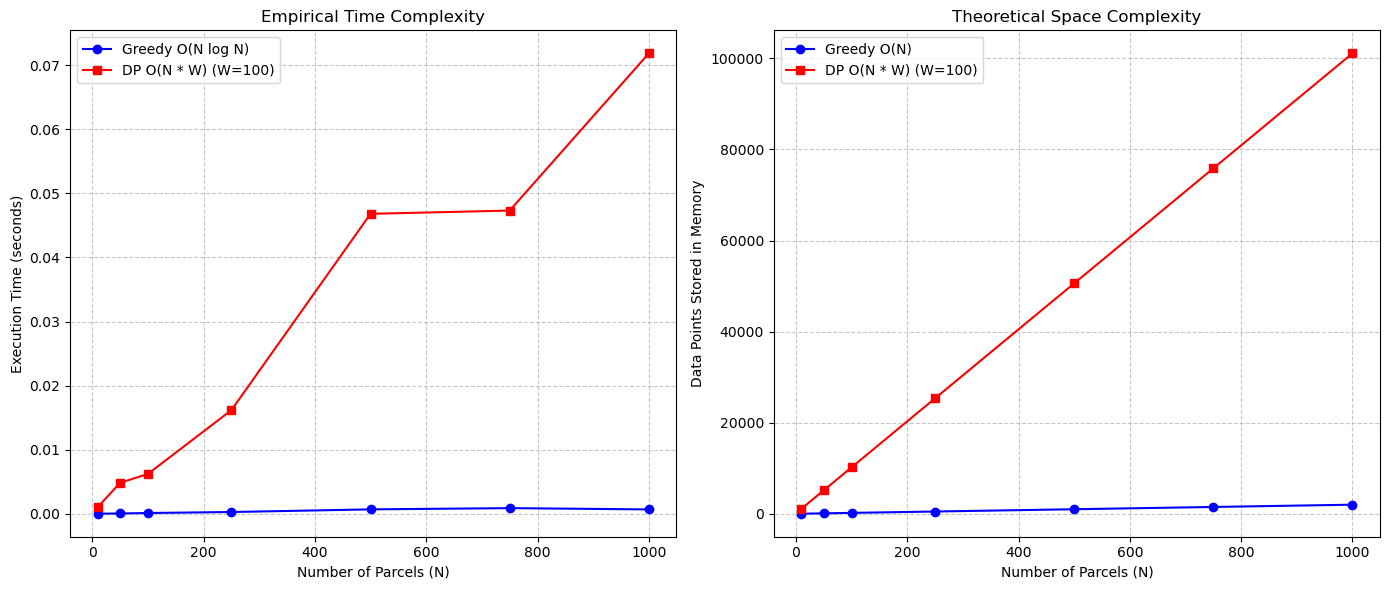

In [7]:
# Dummy data from previous setup to make the code runnable
parcels = {
    "P1": {"val": 150, "wt": 15, "window": (0, 60)},
    "P2": {"val": 80,  "wt": 25, "window": (20, 90)},
    "P3": {"val": 200, "wt": 20, "window": (10, 120)},
    "P4": {"val": 50,  "wt": 10, "window": (50, 150)}
}
vehicle_capacity = 50
# 1. Greedy Approach (Value-to-Weight Ratio)
# Time Complexity: O(N log N) where N is the number of parcels. 
# Space Complexity: O(N) for storing the sorted list and the selected subset.
def greedy_parcel_selection(parcels, capacity):
    # O(N log N) for sorting
    sorted_parcels = sorted(parcels.items(), key=lambda x: x[1]['val']/x[1]['wt'], reverse=True)
    selected = []
    current_weight = 0
    total_value = 0
    # O(N) for iterating through the sorted parcels
    for pid, data in sorted_parcels:
        if current_weight + data['wt'] <= capacity:
            selected.append(pid)
            current_weight += data['wt']
            total_value += data['val']
    return selected, total_value
# 2. DP Approach (0/1 Knapsack Validation)
# Time Complexity: O(N * W) where N is the number of parcels and 
#                  W is the total vehicle capacity. 
# Space Complexity: O(N * W) 
def dp_parcel_selection(parcels, capacity):
    p_ids = list(parcels.keys())
    n = len(p_ids)
    
    # DP Table: rows = parcels, cols = capacities -> O(N * W) space
    dp = [[0 for _ in range(capacity + 1)] for _ in range(n + 1)]
    
    # Nested loops -> O(N * W) time
    for i in range(1, n + 1):
        pid = p_ids[i-1]
        val = parcels[pid]['val']
        wt = parcels[pid]['wt']
        
        for w in range(1, capacity + 1):
            if wt <= w:
                dp[i][w] = max(dp[i-1][w], dp[i-1][w-wt] + val)
            else:
                dp[i][w] = dp[i-1][w]
                
    return dp[n][capacity] # Max value possible

# Profiling Execution Time

# Measure Greedy Execution Time
start_greedy = time.perf_counter()
greedy_route, greedy_val = greedy_parcel_selection(parcels, vehicle_capacity)
end_greedy = time.perf_counter()
time_greedy = end_greedy - start_greedy

# Measure DP Execution Time
start_dp = time.perf_counter()
dp_val = dp_parcel_selection(parcels, vehicle_capacity)
end_dp = time.perf_counter()
time_dp = end_dp - start_dp

# --- Output Results ---
print("=== ALGORITHM PROFILING RESULTS ===")
print(f"Greedy Selected: {greedy_route} (Value: {greedy_val})")
print(f"Greedy Execution Time: {time_greedy:.8f} seconds\n")
print(f"DP Max Optimal Value: {dp_val}")
print(f"DP Execution Time: {time_dp:.8f} seconds")
"""Complexity Visualization"""
def generate_random_parcels(n):
    """Generates a dictionary of 'n' random parcels for testing."""
    return {f"P{i}": {"val": random.randint(10, 200), "wt": random.randint(5, 40)} for i in range(n)}
def plot_complexity_graphs():
    N_values = [10, 50, 100, 250, 500, 750, 1000]
    test_capacity = 100  # Keep capacity constant to isolate the effect of N
    time_greedy = []
    time_dp = []
    space_greedy = []
    space_dp = []
    print("\nBenchmarking algorithms for complexity graphs... please wait.")
    for n in N_values:
        test_parcels = generate_random_parcels(n)
        # --- Measure Greedy ---
        start_t = time.perf_counter()
        greedy_parcel_selection(test_parcels, test_capacity)
        time_greedy.append(time.perf_counter() - start_t)
        # Space: Greedy stores the sorted list of N items
        space_greedy.append(n * 2) 
        # --- Measure DP ---
        start_t = time.perf_counter()
        dp_parcel_selection(test_parcels, test_capacity)
        time_dp.append(time.perf_counter() - start_t)
        # Space: DP stores a 2D matrix of size (N+1) x (W+1)
        space_dp.append((n + 1) * (test_capacity + 1))
    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    # 1. Time Complexity Graph
    ax1.plot(N_values, time_greedy, label="Greedy O(N log N)", marker='o', color='blue')
    ax1.plot(N_values, time_dp, label=f"DP O(N * W) (W={test_capacity})", marker='s', color='red')
    ax1.set_title("Empirical Time Complexity")
    ax1.set_xlabel("Number of Parcels (N)")
    ax1.set_ylabel("Execution Time (seconds)")
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()
    # 2. Space Complexity Graph
    ax2.plot(N_values, space_greedy, label="Greedy O(N)", marker='o', color='blue')
    ax2.plot(N_values, space_dp, label=f"DP O(N * W) (W={test_capacity})", marker='s', color='red')
    ax2.set_title("Theoretical Space Complexity")
    ax2.set_xlabel("Number of Parcels (N)")
    ax2.set_ylabel("Data Points Stored in Memory")
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend()
    plt.tight_layout()
    plt.show()
# Run the visualization
plot_complexity_graphs()

Dijkstra Shortest Path (0 to 4): [0, 4] with length 30
MST Edges: [(0, 1, {'weight': 12}), (0, 2, {'weight': 18}), (2, 3, {'weight': 15}), (3, 4, {'weight': 10})]


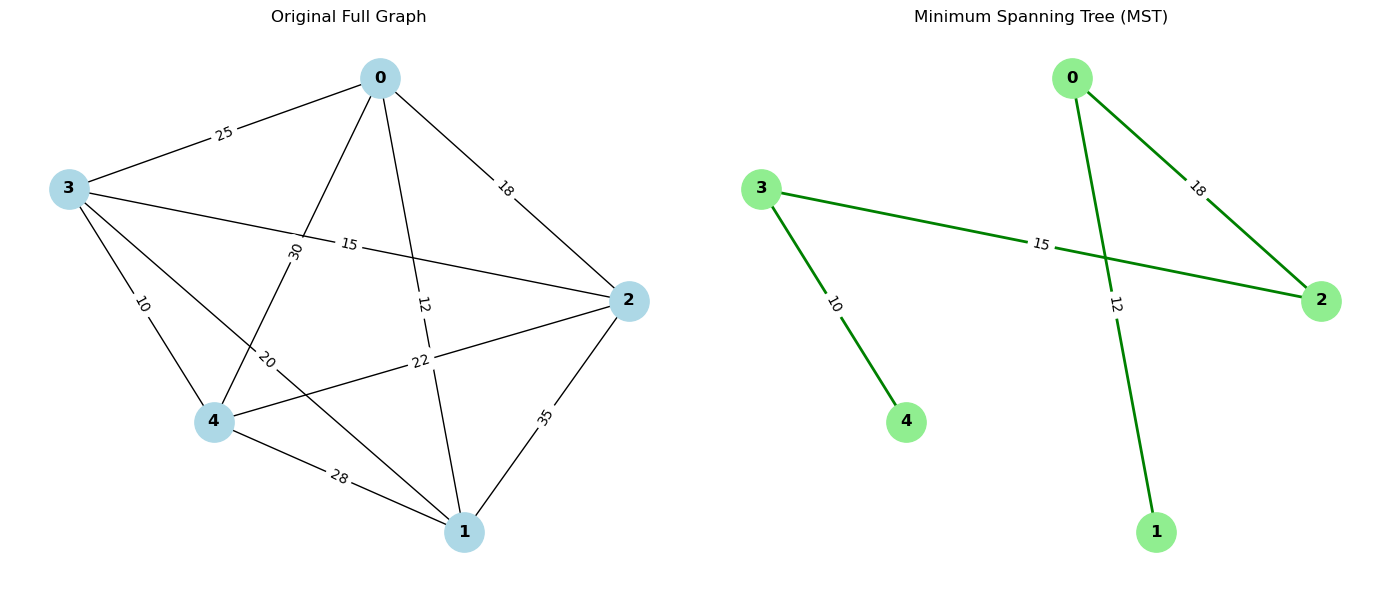

In [12]:
# 1. Build the Graph
# Time Complexity: O(V^2) where V is the number of vertices, because we iterate over the upper triangle of the matrix.
# Space Complexity: O(V + E) to store the graph (in a complete graph, E = V(V-1)/2, so O(V^2)).
G = nx.Graph()
for i in range(len(dist_matrix)):
    for j in range(i + 1, len(dist_matrix)):
        G.add_edge(i, j, weight=dist_matrix[i][j])
# 2. Dijkstra's Algorithm
# Time Complexity: O((V + E) log V) using a min-priority queue (NetworkX uses a Fibonacci-like heap internally).
# Space Complexity: O(V) to store the distances and the path.
shortest_path = nx.dijkstra_path(G, source=0, target=4, weight='weight')
path_length = nx.dijkstra_path_length(G, source=0, target=4, weight='weight')
print(f"Dijkstra Shortest Path (0 to 4): {shortest_path} with length {path_length}")
# 3. Minimum Spanning Tree (MST)
# Time Complexity: O(E log E) or O(E log V) using Kruskal's Algorithm (NetworkX's default for MST).
# Space Complexity: O(V + E) to store the new MST graph structure.
mst = nx.minimum_spanning_tree(G)
print(f"MST Edges: {mst.edges(data=True)}")
# 4. Visualization (Original Graph vs MST)
# Set a consistent layout so both graphs align perfectly visually
pos = nx.spring_layout(G, seed=42) 
plt.figure(figsize=(14, 6))
# Plot 1: Original Graph
plt.subplot(1, 2, 1)
plt.title("Original Full Graph")
# Draw nodes and edges
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=800, font_weight='bold')
# Draw edge weight labels
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
# Plot 2: Minimum Spanning Tree (MST)
plt.subplot(1, 2, 2)
plt.title("Minimum Spanning Tree (MST)")
# Draw nodes and edges for MST
nx.draw(mst, pos, with_labels=True, node_color='lightgreen', node_size=800, font_weight='bold', edge_color='green', width=2)
# Draw edge weight labels for MST
mst_edge_labels = nx.get_edge_attributes(mst, 'weight')
nx.draw_networkx_edge_labels(mst, pos, edge_labels=mst_edge_labels)
plt.tight_layout()
plt.show()

In [7]:

def solve_tsp_brute_force(dist_matrix):
    n = len(dist_matrix)
    customers = list(range(1, n))
    
    min_cost = float('inf')
    best_route = []
    
    # Generate all possible paths through customers
    for perm in itertools.permutations(customers):
        # Route: Warehouse -> Customers -> Warehouse
        current_route = [0] + list(perm) + [0]
        cost = recursive_route_cost(current_route, dist_matrix)
        
        if cost < min_cost:
            min_cost = cost
            best_route = current_route
            
    return best_route, min_cost

tsp_route, tsp_dist = solve_tsp_brute_force(dist_matrix)
print(f"Optimal TSP Route: {tsp_route} with total distance: {tsp_dist}")

Optimal TSP Route: [0, 1, 3, 4, 2, 0] with total distance: 82


=== TSP PROFILING & COMPLEXITY ===
TSP Execution Time: 0.000884 seconds
Time Complexity: O(N!) - Scales factorially
Space Complexity: O(N) - Scales linearly



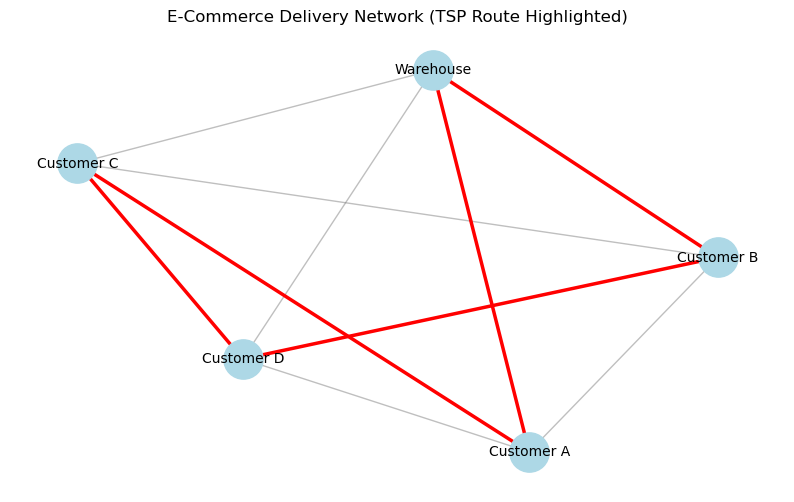

Benchmarking TSP Time & Space Complexity (N=4 to 10)...


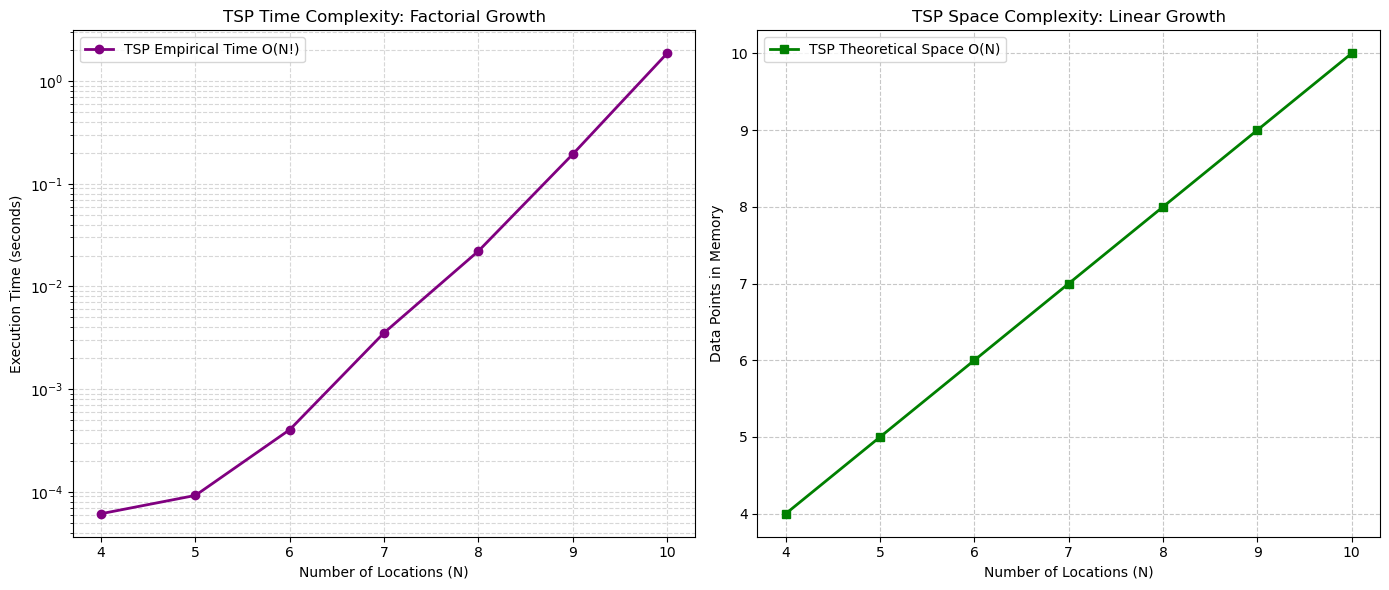

In [22]:
import time
import random
import itertools
import networkx as nx
import matplotlib.pyplot as plt
# --- Dummy Data to make the script fully runnable ---
locations = ["Warehouse", "Customer A", "Customer B", "Customer C", "Customer D"]
dist_matrix = [
    [0, 12, 18, 25, 30],
    [12, 0, 35, 20, 28],
    [18, 35, 0, 15, 22],
    [25, 20, 15, 0, 10],
    [30, 28, 22, 10, 0]
]

# Provide the base TSP function needed for the first block
def solve_tsp_brute_force(matrix):
    n = len(matrix)
    customers = list(range(1, n))
    min_cost = float('inf')
    best_route = []
    
    for perm in itertools.permutations(customers):
        current_route = [0] + list(perm) + [0]
        cost = sum(matrix[current_route[i]][current_route[i+1]] for i in range(len(current_route)-1))
        if cost < min_cost:
            min_cost = cost
            best_route = current_route
            
    return best_route, min_cost
# 1. TSP PROFILING & SINGLE ROUTE VISUALIZATION
print("=== TSP PROFILING & COMPLEXITY ===")
start_time = time.time()
tsp_route, tsp_dist = solve_tsp_brute_force(dist_matrix) 
end_time = time.time()
print(f"TSP Execution Time: {end_time - start_time:.6f} seconds")
print("Time Complexity: O(N!) - Scales factorially")
print("Space Complexity: O(N) - Scales linearly\n")
# Build the Graph for visualization
G = nx.Graph()
for i in range(len(dist_matrix)):
    for j in range(i + 1, len(dist_matrix)):
        G.add_edge(i, j, weight=dist_matrix[i][j])
def plot_network_and_route(G, locations, tsp_route):
    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(G, seed=42) 
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=800)
    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5)
    labels = {i: locations[i] for i in range(len(locations))}
    nx.draw_networkx_labels(G, pos, labels, font_size=10)
    
    tsp_edges = [(tsp_route[i], tsp_route[i+1]) for i in range(len(tsp_route)-1)]
    nx.draw_networkx_edges(G, pos, edgelist=tsp_edges, edge_color='red', width=2.5)
    
    plt.title("E-Commerce Delivery Network (TSP Route Highlighted)")
    plt.axis('off')
    plt.show() 
# Show the route graph
plot_network_and_route(G, locations, tsp_route)
# 2. TIME & SPACE COMPLEXITY GRAPHS
def solve_tsp_brute_force_benchmark(matrix):
    n = len(matrix)
    customers = list(range(1, n))
    min_cost = float('inf')
    best_route = []
    
    for perm in itertools.permutations(customers):
        current_route = [0] + list(perm) + [0]
        cost = sum(matrix[current_route[i]][current_route[i+1]] for i in range(len(current_route)-1))
        if cost < min_cost:
            min_cost = cost
            best_route = current_route
    return best_route, min_cost

def plot_tsp_complexity():
    # CAUTION: Do not increase N beyond 11 unless you want to wait a very long time!
    N_values = [4, 5, 6, 7, 8, 9, 10] 
    
    time_tsp = []
    space_tsp = []
    
    print("Benchmarking TSP Time & Space Complexity (N=4 to 10)...")
    
    for n in N_values:
        # Generate a random N x N distance matrix
        rand_dist_matrix = [[random.randint(10, 50) if i != j else 0 for j in range(n)] for i in range(n)]
        
        # --- Measure Time Complexity ---
        start_t = time.perf_counter()
        solve_tsp_brute_force_benchmark(rand_dist_matrix)
        time_tsp.append(time.perf_counter() - start_t)
        # --- Measure Space Complexity ---
        # Space is O(N) because itertools.permutations yields one route at a time
        space_tsp.append(n)
    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    # 1. Time Complexity Graph O(N!)
    ax1.plot(N_values, time_tsp, label="TSP Empirical Time O(N!)", marker='o', color='purple', linewidth=2)
    ax1.set_title("TSP Time Complexity: Factorial Growth")
    ax1.set_xlabel("Number of Locations (N)")
    ax1.set_ylabel("Execution Time (seconds)")
    ax1.set_yscale('log') 
    ax1.grid(True, which="both", ls="--", alpha=0.5)
    ax1.legend()
    # 2. Space Complexity Graph O(N)
    ax2.plot(N_values, space_tsp, label="TSP Theoretical Space O(N)", marker='s', color='green', linewidth=2)
    ax2.set_title("TSP Space Complexity: Linear Growth")
    ax2.set_xlabel("Number of Locations (N)")
    ax2.set_ylabel("Data Points in Memory")
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend()
    plt.tight_layout()
    plt.show()
# Show the complexity graphs
plot_tsp_complexity()